# 11 — Illustration: climatological noising of an input field (Q1000, Europe)

**Purpose**: a single, intuitive picture of what "patching an input field with climatology" (notebook 08) actually does to the data, before diving into the causal-ablation results. We take one field -- specific humidity at 1000 hPa (`Q1000`) -- over Europe, at init `2024-03-25T18:00`, and progressively blend it toward its 30-year climatological norm (WeatherBench2/ERA5 climatology, 1990-2019, matched by day-of-year and hour):

```
patched(alpha) = (1 - alpha) * real + alpha * climatology
```

for `alpha in {0, 0.2, 0.4, 0.6, 0.8, 1.0}`. `alpha=0` is the untouched real field; `alpha=1` is pure climatology -- all case-specific information (the actual synoptic situation on that day) is gone, replaced by "what's normal for this day of year at this hour".

This is exactly the noising primitive used inside `08_input_patching.ipynb` / `run_patching_experiment.py`, just applied at fractional strength and visualized directly on the input, without re-running Aurora.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

plt.rcParams['figure.dpi'] = 110
FIG_DIR = 'figures/11_humidity_noising_illustration'
os.makedirs(FIG_DIR, exist_ok=True)

DATA_ROOT = 'data'  # -> data/ symlink to /srv/exw/data/irina_weather_interpretability
INIT_TIME = np.datetime64('2024-03-25T18:00')
LEVEL = 1000
EUROPE_LON = (-40, 30)   # same regional extent as 01_era5_visualization.ipynb
EUROPE_LAT = (30, 70)
ALPHAS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

## 1. Load the real field (ERA5, 2024) and the climatology (WB2/ERA5, 1990-2019, 30y mean)

In [2]:
ds_upper = xr.open_zarr(f'{DATA_ROOT}/era5_2024_2025_6h_upper.zarr', chunks=None)
clim_upper = xr.open_zarr(f'{DATA_ROOT}/climatology_1990-2019_upper_500_850_1000.zarr', chunks=None)

# ARCO/ERA5-style longitude is 0..359.75; convert to -180..180 and sort, same fix as notebook 01,
# so the Europe crop doesn't hit a seam at lon=0.
def to_pm180(ds):
    return ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby('longitude')

ds_upper = to_pm180(ds_upper)
clim_upper = to_pm180(clim_upper)

ts = pd.Timestamp(INIT_TIME)
doy = min(ts.dayofyear, 366)
hour = (ts.hour // 6) * 6
print(f'init={INIT_TIME}  ->  climatology lookup: dayofyear={doy}, hour={hour}')

real_q1000 = (
    ds_upper['specific_humidity']
    .sel(time=INIT_TIME, level=LEVEL)
    .sel(longitude=slice(*EUROPE_LON), latitude=slice(EUROPE_LAT[1], EUROPE_LAT[0]))
    .load()
)
clim_q1000 = (
    clim_upper['specific_humidity']
    .sel(dayofyear=doy, hour=hour, level=LEVEL)
    .sel(longitude=slice(*EUROPE_LON), latitude=slice(EUROPE_LAT[1], EUROPE_LAT[0]))
    .load()
)

print('real shape:', real_q1000.shape, ' clim shape:', clim_q1000.shape)
print('real range (kg/kg):', float(real_q1000.min()), float(real_q1000.max()))
print('clim range (kg/kg):', float(clim_q1000.min()), float(clim_q1000.max()))

init=2024-03-25T18:00  ->  climatology lookup: dayofyear=85, hour=18
real shape: (161, 281)  clim shape: (161, 281)
real range (kg/kg): 0.0002336706966161728 0.011108051054179668
clim range (kg/kg): 0.0004556860658340156 0.009312232956290245


## 2. Build the alpha-blend series and plot

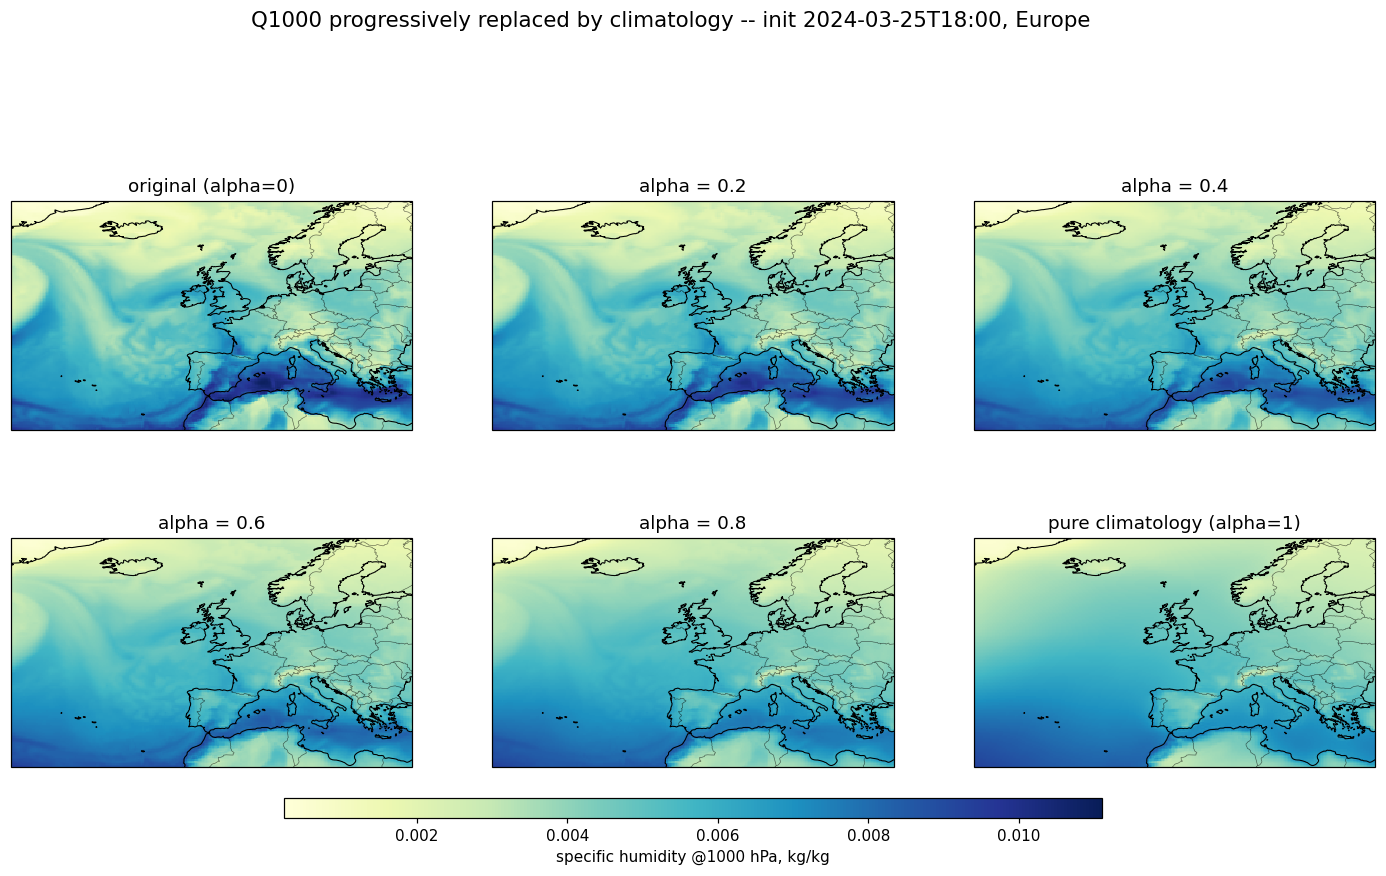

In [3]:
blends = {alpha: (1 - alpha) * real_q1000 + alpha * clim_q1000 for alpha in ALPHAS}

vmin = min(float(f.min()) for f in blends.values())
vmax = max(float(f.max()) for f in blends.values())

fig, axes = plt.subplots(2, 3, figsize=(16, 9),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax, alpha in zip(axes.flat, ALPHAS):
    field = blends[alpha]
    ax.set_extent([*EUROPE_LON, *EUROPE_LAT], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.6)
    im = ax.pcolormesh(field.longitude, field.latitude, field.values,
                        transform=ccrs.PlateCarree(), cmap='YlGnBu', vmin=vmin, vmax=vmax)
    title = 'original (alpha=0)' if alpha == 0 else ('pure climatology (alpha=1)' if alpha == 1 else f'alpha = {alpha}')
    ax.set_title(title)

fig.suptitle(f'Q1000 progressively replaced by climatology -- init {INIT_TIME}, Europe', fontsize=14, y=1.02)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', shrink=0.6, pad=0.04, aspect=40)
cbar.set_label('specific humidity @1000 hPa, kg/kg')
plt.savefig(f'{FIG_DIR}/q1000_noising_series_europe.png', dpi=150, bbox_inches='tight')
plt.show()

As `alpha` increases from 0 to 1, the real synoptic structure (moisture plumes, fronts, dry/moist contrasts tied to the actual 2024-03-25 weather situation) is progressively washed out and replaced by the smooth 30-year day-of-year/hour climatological norm. At `alpha=1` the field carries no information about this specific day at all -- only about what is typical for late March at 18:00 UTC, averaged over 1990-2019. This is the same operation `08_input_patching.ipynb` applies at `alpha=1` (full climatological patch) to one input component before feeding it to Aurora; here we look at the raw input field directly, at intermediate blend strengths, to make the ablation's effect on the data itself visible.